# EDA
## ADSP 32023 - Advanced Computer Vision Using Deep Learning
## Spring 2026

In [1]:
# ============================================================
# 0. Imports
# ============================================================
import os
import cv2
import json
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# 1. Graph save directory
# ============================================================
PROJECT_DIR = Path(
    "/content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project"
)

DATA_DIR = PROJECT_DIR / "data" / "eda"
GRAPH_DIR = PROJECT_DIR / "graphs" / "eda"

DATA_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("GRAPH_DIR:", GRAPH_DIR)

DATA_DIR: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/data/eda
GRAPH_DIR: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/graphs/eda


In [3]:
# ============================================================
# 2. Download dataset
# ============================================================
path = kagglehub.dataset_download("philosopher0808/gym-workoutexercises-video")
DATASET_PATH = Path(path)

print("Path to dataset files:", DATASET_PATH)
print("Top-level folders:")
for item in sorted(DATASET_PATH.iterdir()):
    print(" -", item.name)

100%|██████████| 9.63G/9.63G [01:41<00:00, 102MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/philosopher0808/gym-workoutexercises-video/versions/1
Top-level folders:
 - raw_data
 - test
 - verified_data


In [4]:
# ============================================================
# 3. Collect only train and test videos
# ============================================================
VIDEO_EXTS = (".mp4", ".mov", ".avi", ".mkv", ".webm")

rows = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(VIDEO_EXTS):
            file_path = Path(root) / file
            rel_parts = file_path.relative_to(DATASET_PATH).parts

            top_level = rel_parts[0] if len(rel_parts) > 0 else "unknown"

            # Keep verified_data as train and test as test
            if top_level not in ["verified_data", "test"]:
                continue

            split = "train" if top_level == "verified_data" else "test"
            exercise = rel_parts[-2].strip()

            rows.append({
                "filepath": str(file_path),
                "filename": file,
                "original_split": top_level,
                "split": split,
                "exercise": exercise
            })

df = pd.DataFrame(rows)

print("Total train/test videos:", len(df))
print("Number of exercises:", df["exercise"].nunique())
display(df.head())

Total train/test videos: 1632
Number of exercises: 22


,filepath,filename,original_split,split,exercise
0,/root/.cache/kagglehub/datasets/philosopher080...,c6b4503f-ca8a-40cd-9d81-85a5f846cc76.mp4,verified_data,train,pull Up
1,/root/.cache/kagglehub/datasets/philosopher080...,bba620bb-7ebf-4075-a025-47d9d5246615.mp4,verified_data,train,pull Up
2,/root/.cache/kagglehub/datasets/philosopher080...,f2ed5d24-ee9a-414b-9742-3781dc2ef713.mp4,verified_data,train,pull Up
3,/root/.cache/kagglehub/datasets/philosopher080...,ca6c46a7-b599-4e11-92cb-58336c77fc81.mp4,verified_data,train,pull Up
4,/root/.cache/kagglehub/datasets/philosopher080...,750d7f07-0a1e-4d6f-b2f3-50d478103dec.mp4,verified_data,train,pull Up


In [5]:
# ============================================================
# 4. Basic counts
# ============================================================
print("Videos by split:")
display(df["split"].value_counts().to_frame("num_videos"))

print("Videos by exercise and split:")

exercise_split_counts = (
    df.groupby(["exercise", "split"])
      .size()
      .unstack(fill_value=0)
)

exercise_split_counts = exercise_split_counts.rename(columns={
    "train": "train_videos",
    "test": "test_videos"
})

if "train_videos" not in exercise_split_counts.columns:
    exercise_split_counts["train_videos"] = 0

if "test_videos" not in exercise_split_counts.columns:
    exercise_split_counts["test_videos"] = 0

exercise_split_counts["total_videos"] = (
    exercise_split_counts["train_videos"] + exercise_split_counts["test_videos"]
)

exercise_split_counts = exercise_split_counts.sort_values(
    "total_videos",
    ascending=False
)

display(exercise_split_counts)

Videos by split:


,num_videos
split,
train,1571
test,61


Videos by exercise and split:


split,test_videos,train_videos,total_videos
exercise,,,
plank,2,151,153
barbell biceps curl,2,111,113
bench press,3,94,97
squat,3,87,90
push-up,2,83,85
decline bench press,3,81,84
chest fly machine,4,76,80
hammer curl,3,73,76
incline bench press,3,72,75


In [6]:
# ============================================================
# 5. Video metadata extraction
# ============================================================
def get_video_info(video_path):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return {
            "width": np.nan,
            "height": np.nan,
            "fps": np.nan,
            "frame_count": np.nan,
            "duration": np.nan,
            "corrupted": True
        }

    width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)

    cap.release()

    if fps is None or fps <= 0 or frame_count is None or frame_count <= 0:
        return {
            "width": width,
            "height": height,
            "fps": fps,
            "frame_count": frame_count,
            "duration": np.nan,
            "corrupted": True
        }

    duration = frame_count / fps

    return {
        "width": width,
        "height": height,
        "fps": fps,
        "frame_count": frame_count,
        "duration": duration,
        "corrupted": False
    }


metadata_rows = []

for fp in tqdm(df["filepath"], desc="Reading video metadata"):
    metadata_rows.append(get_video_info(fp))

metadata_df = pd.DataFrame(metadata_rows)

df = pd.concat(
    [df.reset_index(drop=True), metadata_df],
    axis=1
)

df["resolution"] = (
    df["width"].fillna(-1).astype(int).astype(str)
    + "x"
    + df["height"].fillna(-1).astype(int).astype(str)
)

display(df.head())

Reading video metadata: 100%|██████████| 1632/1632 [00:37<00:00, 43.25it/s]


,filepath,filename,original_split,split,exercise,width,height,fps,frame_count,duration,corrupted,resolution
0,/root/.cache/kagglehub/datasets/philosopher080...,c6b4503f-ca8a-40cd-9d81-85a5f846cc76.mp4,verified_data,train,pull Up,720.0,1280.0,60.00000,600.0,10.000000,False,720x1280
1,/root/.cache/kagglehub/datasets/philosopher080...,bba620bb-7ebf-4075-a025-47d9d5246615.mp4,verified_data,train,pull Up,608.0,1080.0,30.00000,300.0,10.000000,False,608x1080
2,/root/.cache/kagglehub/datasets/philosopher080...,f2ed5d24-ee9a-414b-9742-3781dc2ef713.mp4,verified_data,train,pull Up,720.0,1280.0,60.00000,600.0,10.000000,False,720x1280
3,/root/.cache/kagglehub/datasets/philosopher080...,ca6c46a7-b599-4e11-92cb-58336c77fc81.mp4,verified_data,train,pull Up,608.0,1080.0,30.00000,121.0,4.033333,False,608x1080
4,/root/.cache/kagglehub/datasets/philosopher080...,750d7f07-0a1e-4d6f-b2f3-50d478103dec.mp4,verified_data,train,pull Up,1920.0,1080.0,29.97003,300.0,10.010000,False,1920x1080


In [7]:
# ============================================================
# 6. Split into train and test data
# ============================================================
train_df = df[
    (df["split"] == "train") &
    (~df["corrupted"])
].reset_index(drop=True)

test_df = df[
    (df["split"] == "test") &
    (~df["corrupted"])
].reset_index(drop=True)

print("Train videos:", len(train_df))
print("Test videos:", len(test_df))
print("Train classes:", train_df["exercise"].nunique())
print("Test classes:", test_df["exercise"].nunique())

Train videos: 1571
Test videos: 61
Train classes: 22
Test classes: 22


In [8]:
# ============================================================
# 7. Optional: remove plank for rep-count app
# ============================================================
REMOVE_PLANK = True

if REMOVE_PLANK:
    train_df = train_df[train_df["exercise"] != "plank"].reset_index(drop=True)
    test_df = test_df[test_df["exercise"] != "plank"].reset_index(drop=True)

print("After plank removal:")
print("Train videos:", len(train_df))
print("Test videos:", len(test_df))
print("Train classes:", train_df["exercise"].nunique())
print("Test classes:", test_df["exercise"].nunique())

After plank removal:
Train videos: 1420
Test videos: 59
Train classes: 21
Test classes: 21


In [9]:
# ============================================================
# 8. Corruption summary
# ============================================================
print("Total corrupted videos in train/test:", df["corrupted"].sum())
print("Corruption rate:", df["corrupted"].mean())

print("\nCorruption by split:")
display(df.groupby("split")["corrupted"].agg(["sum", "mean", "count"]))

Total corrupted videos in train/test: 0
Corruption rate: 0.0

Corruption by split:


,sum,mean,count
split,,,
test,0,0.0,61
train,0,0.0,1571


In [10]:
# ============================================================
# 9. Duration/resolution/FPS summary
# ============================================================
print("Train duration stats:")
display(train_df["duration"].describe())

print("Test duration stats:")
display(test_df["duration"].describe())

print("Train top resolutions:")
display(train_df["resolution"].value_counts().head(10).to_frame("count"))

print("Test top resolutions:")
display(test_df["resolution"].value_counts().head(10).to_frame("count"))

print("Train FPS stats:")
display(train_df["fps"].describe())

print("Test FPS stats:")
display(test_df["fps"].describe())

Train duration stats:


,duration
count,1420.000000
mean,7.864671
std,3.089400
min,1.001000
25%,5.005000
50%,10.000000
75%,10.010000
max,13.913900


Test duration stats:


,duration
count,59.000000
mean,18.780795
std,11.675071
min,4.070733
25%,11.833333
50%,14.880000
75%,21.303333
max,56.100000


Train top resolutions:


...

,count
resolution,
720x1280,15
1920x1080,14
406x720,11
1280x720,5
576x720,3
608x1080,2
404x720,1
620x480,1
270x480,1


Train FPS stats:


,fps
count,1420.000000
mean,29.606408
std,6.457328
min,19.750000
25%,25.000000
50%,29.970030
75%,29.970030
max,60.000000


Test FPS stats:


,fps
count,59.000000
mean,28.734889
std,5.063608
min,15.822000
25%,25.000000
50%,29.970030
75%,30.000000
max,60.000000


In [11]:
# ============================================================
# 10. Exercise-level stats for train data
# ============================================================
train_exercise_stats = (
    train_df.groupby("exercise")
    .agg(
        num_videos=("filepath", "count"),
        avg_duration=("duration", "mean"),
        median_duration=("duration", "median"),
        min_duration=("duration", "min"),
        max_duration=("duration", "max"),
        avg_fps=("fps", "mean"),
        common_resolution=(
            "resolution",
            lambda x: x.value_counts().index[0] if len(x) else None
        )
    )
    .sort_values("num_videos", ascending=False)
)

display(train_exercise_stats)

,num_videos,avg_duration,median_duration,min_duration,max_duration,avg_fps,common_resolution
exercise,,,,,,,
barbell biceps curl,111,6.386791,6.700000,1.634967,13.566667,29.618682,1920x1080
bench press,94,5.563705,4.140000,1.200000,11.011000,28.758499,1920x1080
squat,87,8.734783,10.000000,1.960292,12.612600,28.546752,1280x720
push-up,83,6.777922,5.005000,2.736067,13.713700,33.256190,1920x1080
decline bench press,81,9.505710,10.010000,2.836167,12.866667,32.391631,1920x1080
chest fly machine,76,7.879813,10.000000,2.600000,12.800000,29.574596,1920x1080
hammer curl,73,8.906718,10.000000,1.700000,13.913900,31.271249,1920x1080
incline bench press,72,7.085555,10.000000,1.334667,10.750000,27.664738,1280x720
deadlift,69,7.543034,10.000000,1.968633,10.075949,28.806393,1920x1080


In [12]:
# ============================================================
# 11. Exercise-level stats for test data
# ============================================================
test_exercise_stats = (
    test_df.groupby("exercise")
    .agg(
        num_videos=("filepath", "count"),
        avg_duration=("duration", "mean"),
        median_duration=("duration", "median"),
        min_duration=("duration", "min"),
        max_duration=("duration", "max"),
        avg_fps=("fps", "mean"),
        common_resolution=(
            "resolution",
            lambda x: x.value_counts().index[0] if len(x) else None
        )
    )
    .sort_values("num_videos", ascending=False)
)

display(test_exercise_stats)

,num_videos,avg_duration,median_duration,min_duration,max_duration,avg_fps,common_resolution
exercise,,,,,,,
chest fly machine,4,21.637108,15.677550,10.633333,44.560000,27.492507,720x1280
decline bench press,3,23.296511,13.633333,12.579233,43.676967,29.980020,720x1280
bench press,3,14.867449,15.042346,13.880000,15.680000,21.940667,720x1280
hip thrust,3,19.823489,14.266667,8.033333,37.170467,29.990010,720x1280
hammer curl,3,15.320000,15.733333,12.266667,17.960000,28.333333,406x720
tricep dips,3,22.617778,20.640000,14.880000,32.333333,26.666667,720x1280
russian twist,3,9.620000,9.466667,7.033333,12.360000,28.333333,720x1280
incline bench press,3,22.581267,12.400000,11.500000,43.843800,28.323343,406x720
lat pulldown,3,10.182711,10.744067,4.070733,15.733333,29.980020,1280x720


In [13]:
# ============================================================
# 12. Check filename overlap between train and test
# ============================================================
train_filenames = set(train_df["filename"])
test_filenames = set(test_df["filename"])

filename_overlap = train_filenames.intersection(test_filenames)

print("Filename overlap between train and test:", len(filename_overlap))

if len(filename_overlap) > 0:
    overlap_df = df[df["filename"].isin(filename_overlap)].sort_values("filename")
    display(overlap_df)

Filename overlap between train and test: 0


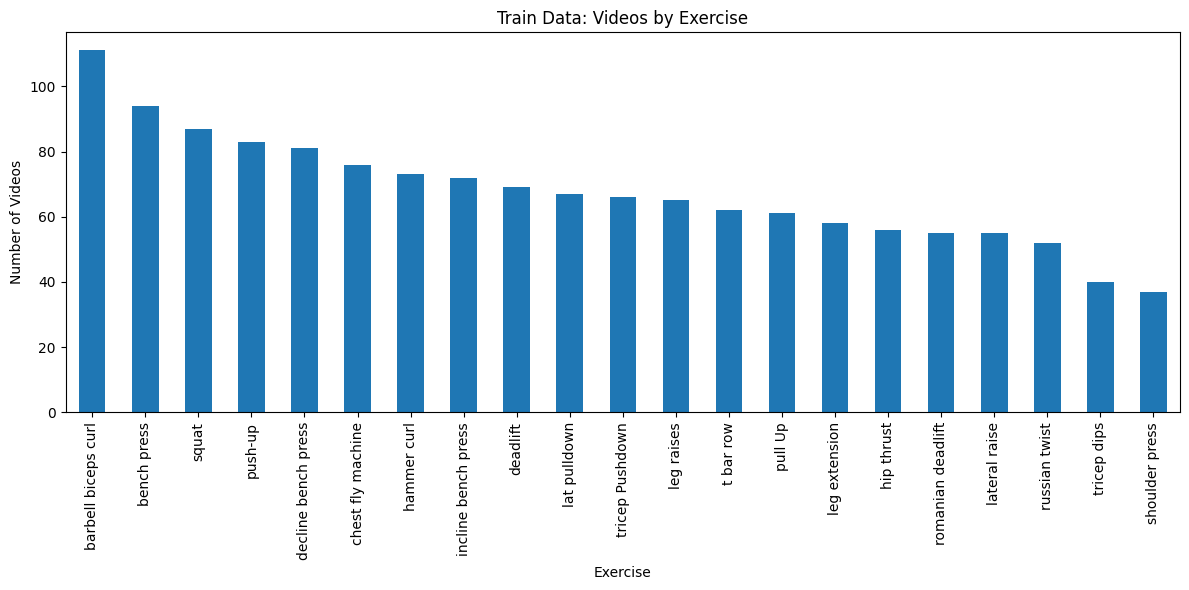

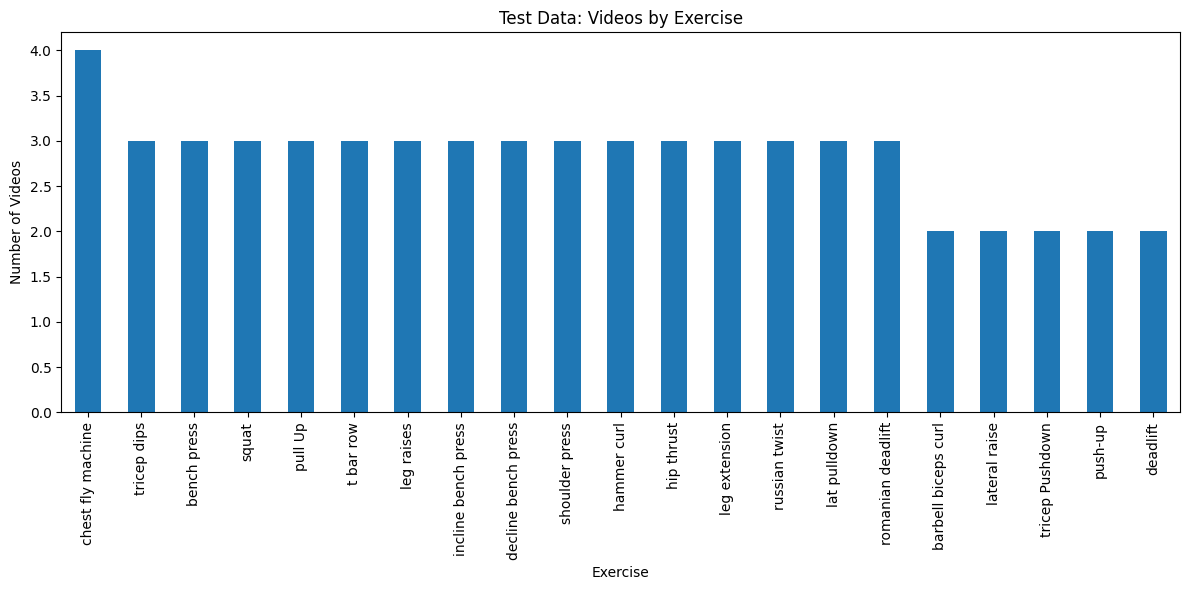

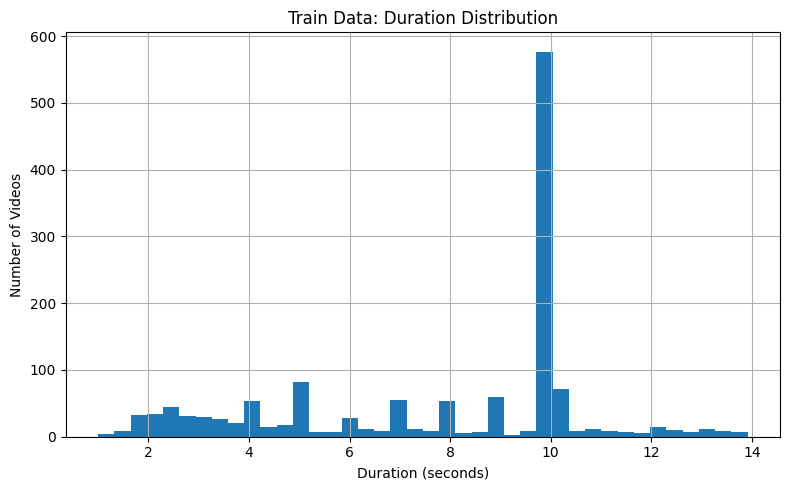

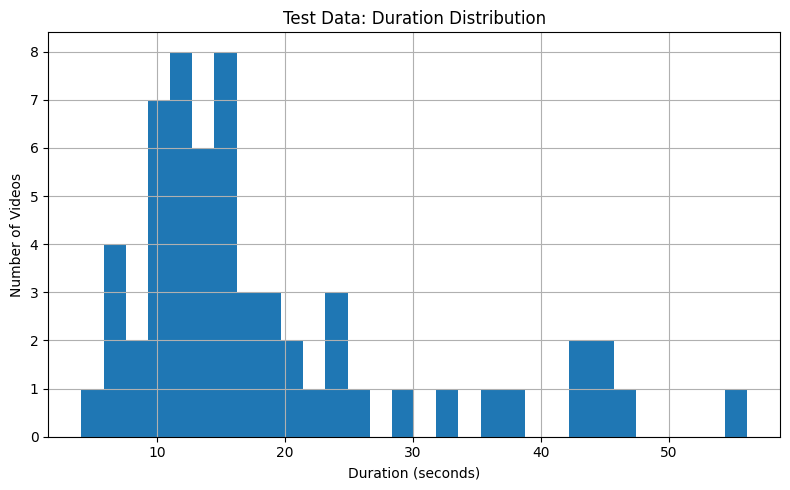

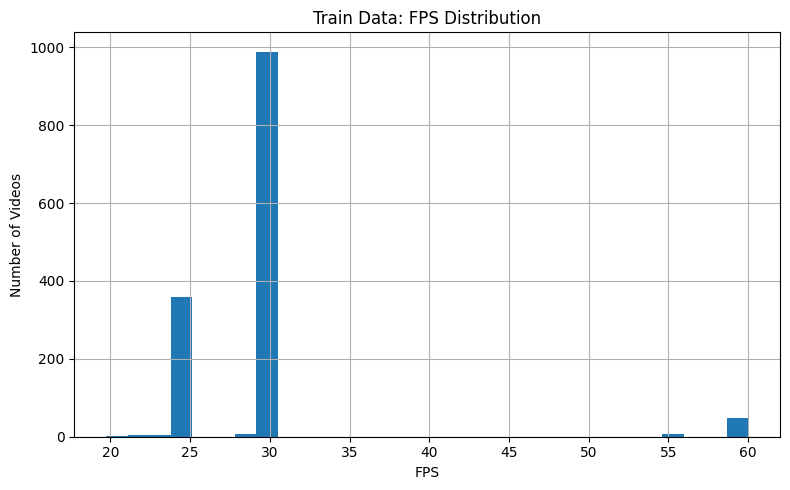

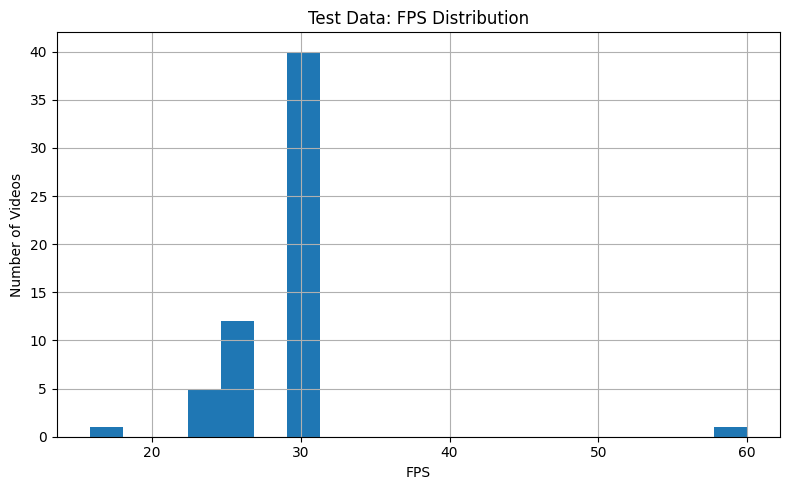

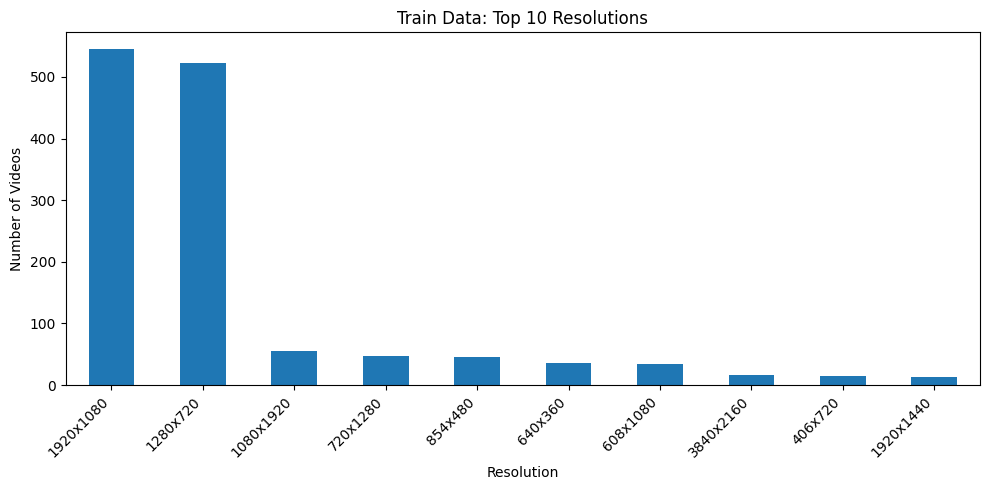

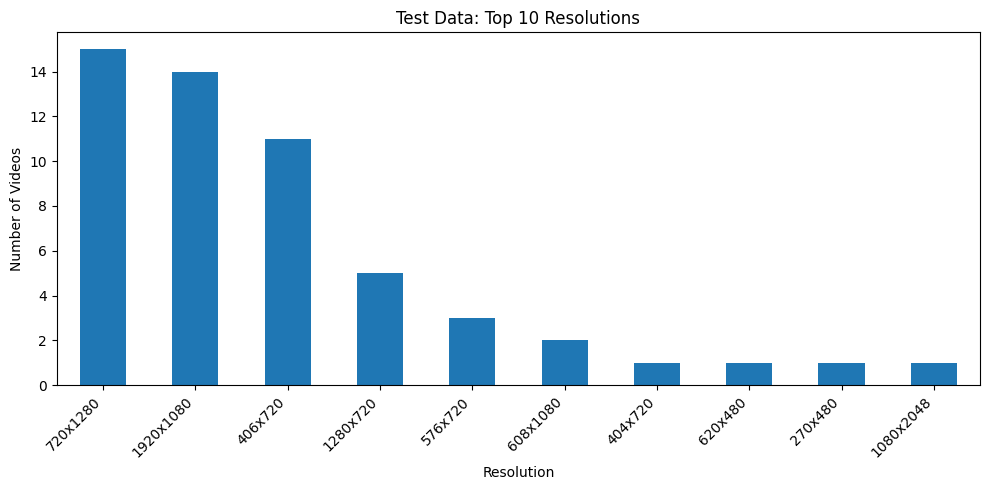

In [14]:
# ============================================================
# 13. Visualizations
# ============================================================

# ------------------------------------------------------------
# Train videos by exercise
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

train_df["exercise"] \
    .value_counts() \
    .sort_values(ascending=False) \
    .plot(kind="bar")

plt.title("Train Data: Videos by Exercise")
plt.xlabel("Exercise")
plt.ylabel("Number of Videos")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    GRAPH_DIR / "train_videos_by_exercise.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Test videos by exercise
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

test_df["exercise"] \
    .value_counts() \
    .sort_values(ascending=False) \
    .plot(kind="bar")

plt.title("Test Data: Videos by Exercise")
plt.xlabel("Exercise")
plt.ylabel("Number of Videos")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    GRAPH_DIR / "test_videos_by_exercise.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Train duration distribution
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

train_df["duration"] \
    .dropna() \
    .hist(bins=40)

plt.title("Train Data: Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Videos")
plt.tight_layout()

plt.savefig(
    GRAPH_DIR / "train_duration_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Test duration distribution
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

test_df["duration"] \
    .dropna() \
    .hist(bins=30)

plt.title("Test Data: Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Videos")
plt.tight_layout()

plt.savefig(
    GRAPH_DIR / "test_duration_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Train FPS distribution
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

train_df["fps"] \
    .dropna() \
    .hist(bins=30)

plt.title("Train Data: FPS Distribution")
plt.xlabel("FPS")
plt.ylabel("Number of Videos")
plt.tight_layout()

plt.savefig(
    GRAPH_DIR / "train_fps_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Test FPS distribution
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

test_df["fps"] \
    .dropna() \
    .hist(bins=20)

plt.title("Test Data: FPS Distribution")
plt.xlabel("FPS")
plt.ylabel("Number of Videos")
plt.tight_layout()

plt.savefig(
    GRAPH_DIR / "test_fps_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Train resolution distribution
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

train_df["resolution"] \
    .value_counts() \
    .head(10) \
    .plot(kind="bar")

plt.title("Train Data: Top 10 Resolutions")
plt.xlabel("Resolution")
plt.ylabel("Number of Videos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    GRAPH_DIR / "train_resolution_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Test resolution distribution
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

test_df["resolution"] \
    .value_counts() \
    .head(10) \
    .plot(kind="bar")

plt.title("Test Data: Top 10 Resolutions")
plt.xlabel("Resolution")
plt.ylabel("Number of Videos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    GRAPH_DIR / "test_resolution_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# ============================================================
# 14. Class imbalance summary
# ============================================================
train_counts = train_df["exercise"].value_counts()

imbalance_summary = pd.DataFrame({
    "exercise": train_counts.index,
    "num_videos": train_counts.values,
    "percent": train_counts.values / train_counts.values.sum() * 100
})

display(imbalance_summary)

print("Largest train class:", train_counts.idxmax(), train_counts.max())
print("Smallest train class:", train_counts.idxmin(), train_counts.min())
print("Imbalance ratio:", train_counts.max() / train_counts.min())

,exercise,num_videos,percent
0,barbell biceps curl,111,7.816901
1,bench press,94,6.619718
2,squat,87,6.126761
3,push-up,83,5.845070
4,decline bench press,81,5.704225
5,chest fly machine,76,5.352113
6,hammer curl,73,5.140845
7,incline bench press,72,5.070423
8,deadlift,69,4.859155
9,lat pulldown,67,4.718310


Largest train class: barbell biceps curl 111
Smallest train class: shoulder press 37
Imbalance ratio: 3.0


In [16]:
# ============================================================
# 15. Save EDA outputs
# ============================================================

# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------
df.to_csv(
    DATA_DIR / "all_train_test_metadata.csv",
    index=False
)

train_df.to_csv(
    DATA_DIR / "train_metadata.csv",
    index=False
)

test_df.to_csv(
    DATA_DIR / "test_metadata.csv",
    index=False
)

train_exercise_stats.to_csv(
    DATA_DIR / "train_exercise_stats.csv"
)

test_exercise_stats.to_csv(
    DATA_DIR / "test_exercise_stats.csv"
)

exercise_split_counts.to_csv(
    DATA_DIR / "exercise_split_counts.csv"
)

imbalance_summary.to_csv(
    DATA_DIR / "class_imbalance_summary.csv",
    index=False
)

if len(filename_overlap) > 0:
    overlap_df.to_csv(
        DATA_DIR / "train_test_filename_overlap.csv",
        index=False
    )

# ------------------------------------------------------------
# Print saved files
# ------------------------------------------------------------
print("\nSaved data files:")
for file in sorted(DATA_DIR.glob("*")):
    print("-", file.name)

print("\nSaved graph files:")
for file in sorted(GRAPH_DIR.glob("*.png")):
    print("-", file.name)


Saved data files:
- all_train_test_metadata.csv
- class_imbalance_summary.csv
- exercise_split_counts.csv
- test_exercise_stats.csv
- test_metadata.csv
- train_exercise_stats.csv
- train_metadata.csv

Saved graph files:
- test_duration_distribution.png
- test_fps_distribution.png
- test_resolution_distribution.png
- test_videos_by_exercise.png
- train_duration_distribution.png
- train_fps_distribution.png
- train_resolution_distribution.png
- train_videos_by_exercise.png
